In [23]:
from langgraph.graph import StateGraph, START, END
from langchain_aws.chat_models import ChatBedrock
import boto3
from typing import TypedDict
from dotenv import load_dotenv
import os

In [24]:
load_dotenv()

True

In [25]:
ACCESS_KEY = os.getenv('AWS_ACCESS_KEY')
SECRET_KEY = os.getenv('AWS_SECRET_KEY')
REGION = os.getenv('AWS_REGION')

In [36]:
from botocore.credentials import RefreshableCredentials
from botocore.session import get_session

ROLE_ARN = os.getenv('ROLE_ARN')

ROLE_SESSION_NAME = "bedrock-session"


sts = boto3.client("sts")
 
response = sts.assume_role(
    RoleArn=ROLE_ARN,
    RoleSessionName="bedrock-session"
)
 
creds = response["Credentials"]
 
session = boto3.Session(
    aws_access_key_id=creds["AccessKeyId"],
    aws_secret_access_key=creds["SecretAccessKey"],
    aws_session_token=creds["SessionToken"],
    region_name=REGION
)

bedrock_client = session.client(
    service_name="bedrock-runtime",
    region_name=REGION
)

In [37]:
provider = os.getenv("PROVIDER")
model_id = os.getenv("MODEL_ID")
model_kwargs = {
    "max_tokens":10000,
    "top_p": 0.9,
}

In [38]:
llm = ChatBedrock(
        client=bedrock_client,
        provider=provider,
        model_id=model_id,  
        model_kwargs=model_kwargs,
        streaming=False
    )

In [39]:
class LLMState(TypedDict):
    question: str
    answer: str

In [40]:
def llm_qa(state:LLMState) -> LLMState:
    query = state['question']
    response = llm.invoke(query)

    state['answer'] = response.content

    return state

In [41]:
graph = StateGraph(LLMState)

graph.add_node('llm_qa', llm_qa)

graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow = graph.compile()

In [42]:
initial_state = {'question': 'Explain mean median and mode in details with example'}

final_state = workflow.invoke(initial_state)
final_state

{'question': 'Explain mean median and mode in details with example',
 'answer': "# Mean, Median, and Mode: Complete Guide\n\n## 1. MEAN (Average)\n\n### Definition\nThe mean is the sum of all values divided by the number of values. It's the most commonly used measure of central tendency.\n\n### Formula\n```\nMean = Sum of all values / Number of values\nMean = Σx / n\n```\n\n### Example\n**Dataset:** 10, 15, 20, 25, 30\n\n```\nMean = (10 + 15 + 20 + 25 + 30) / 5\nMean = 100 / 5\nMean = 20\n```\n\n### Advantages\n✓ Uses all data points\n✓ Easy to calculate\n✓ Good for normally distributed data\n\n### Disadvantages\n✗ Affected by outliers (extreme values)\n✗ Not useful for categorical data\n\n### Real-World Example\n**Student Scores:** 85, 90, 88, 92, 75\n- Mean = (85+90+88+92+75)/5 = **86**\n\n---\n\n## 2. MEDIAN (Middle Value)\n\n### Definition\nThe median is the middle value when data is arranged in order. It divides the dataset into two equal halves.\n\n### How to Find It\n\n**For Odd

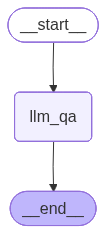

In [43]:
workflow